In [27]:
import sys
from pathlib import Path

# Adding project root to sys.path 
root = Path().resolve().parent 
sys.path.append(str(root))

from config import RAW_DIR, INTERIM_DIR
import pandas as pd

print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)


RAW_DIR: C:\DataProjects\uh-ds-housing-data\data\raw
INTERIM_DIR: C:\DataProjects\uh-ds-housing-data\data\interim


Training tuned Random Forest...

Performance Summary:
Train MAE: 0.289, Test MAE: 0.322
Train R² : 0.642, Test R² : 0.544

Manual 5-Fold CV R² mean: 0.534 ± 0.009


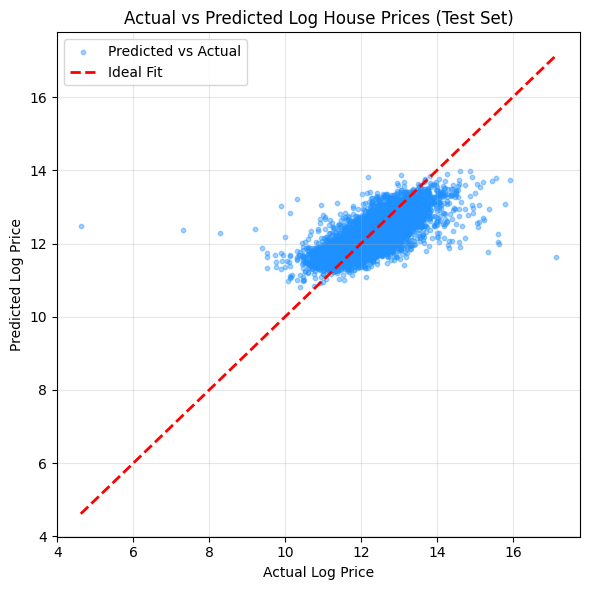

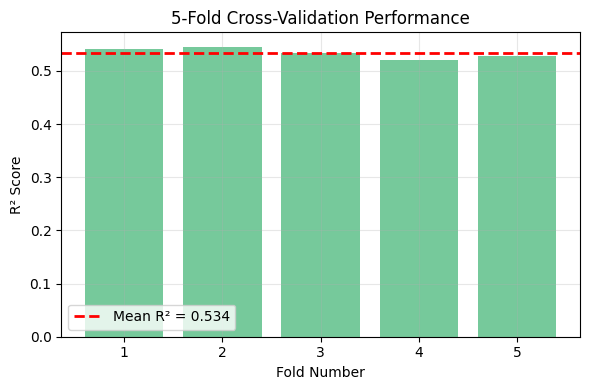

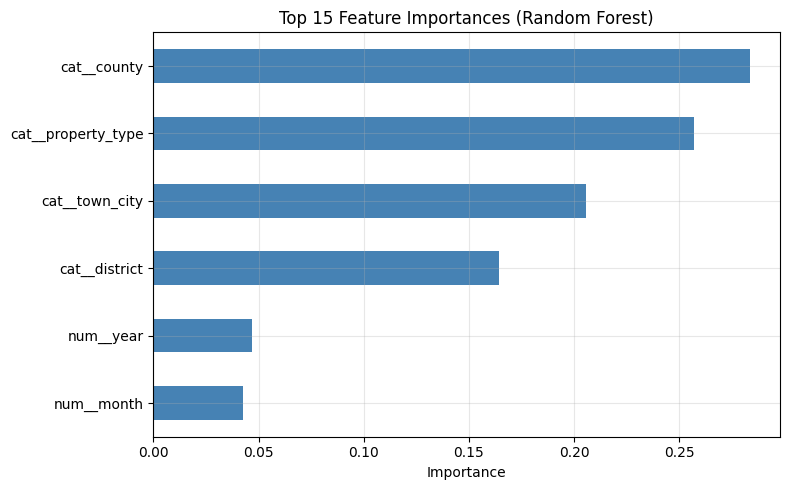


Saved all plots to: C:\DataProjects\uh-ds-housing-data\data\reports\figures


In [28]:
# Random Forest Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

# Load dataset
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, low_memory=False)

# Create directory for saving plots
figures_dir = PROCESSED_DIR.parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Random sample for faster training
df_sample = df.sample(50_000, random_state=42)
features = ["year", "month", "property_type", "county", "district", "town_city"]
target = "log_price"

X = df_sample[features]
y = df_sample[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipelines
num_features = ["year", "month"]
cat_features = [f for f in X_train.columns if f not in num_features]

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

# Random Forest model with regularization
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

model = Pipeline([
    ("prep", preprocessor),
    ("rf", rf)
])

print("Training tuned Random Forest...")
model.fit(X_train, y_train)

# Evaluate on train and test data
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("\nPerformance Summary:")
print(f"Train MAE: {mae_train:.3f}, Test MAE: {mae_test:.3f}")
print(f"Train R² : {r2_train:.3f}, Test R² : {r2_test:.3f}")

# Manual 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    cv_r2.append(r2_score(y_val, preds))

print(f"\nManual 5-Fold CV R² mean: {np.mean(cv_r2):.3f} ± {np.std(cv_r2):.3f}")

# Visualization 1: Actual vs Predicted (Test Set)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=10, color="dodgerblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Ideal Fit")
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Log House Prices (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "rfr_actual_vs_predicted.png", dpi=300)
plt.show()

# Visualization 2: 5-Fold CV R² Distribution
plt.figure(figsize=(6,4))
plt.bar(range(1, 6), cv_r2, color="mediumseagreen", alpha=0.7)
plt.axhline(np.mean(cv_r2), color="red", linestyle="--", linewidth=2,
            label=f"Mean R² = {np.mean(cv_r2):.3f}")
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "rfr_crossval_r2.png", dpi=300)
plt.show()

# Visualization 3: Feature Importances
importances = model.named_steps['rf'].feature_importances_
feature_names = model.named_steps['prep'].get_feature_names_out()
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "rfr_feature_importances.png", dpi=300)
plt.show()

print(f"\nSaved all plots to: {figures_dir}")


Training Random Forest Classifier...

Evaluation Metrics:
Accuracy : 0.773
F1-score : 0.587
ROC-AUC  : 0.865


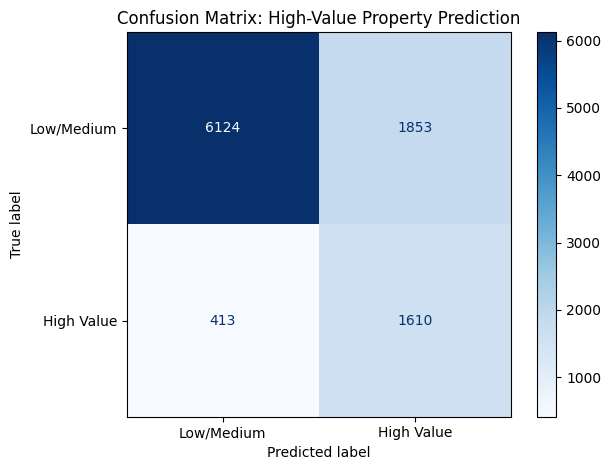

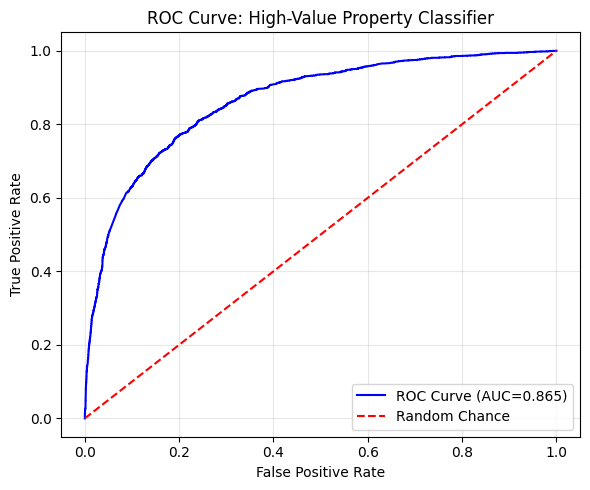

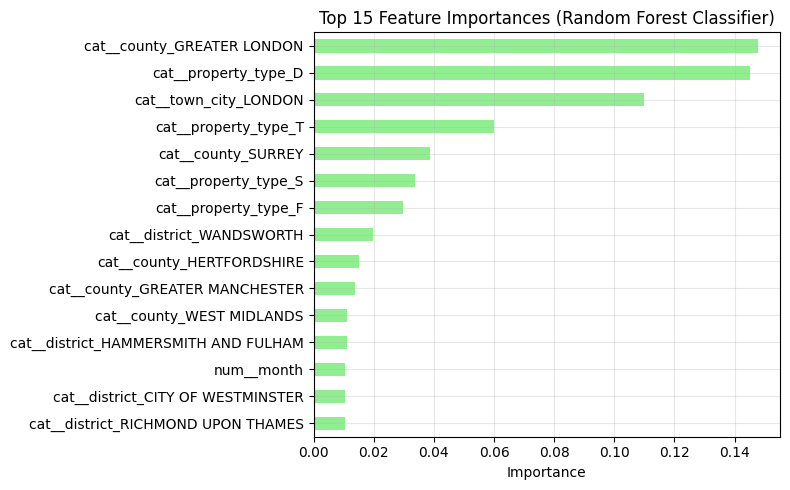

In [29]:
# ============================================
# Random Forest Classification: High-Value Property Prediction
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

# Load dataset
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, low_memory=False)
df_sample = df.sample(50_000, random_state=42).copy()

features = ["year", "month", "property_type", "county", "district", "town_city"]
target = "is_high_value"
X = df_sample[features]
y = df_sample[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = ["year", "month"]
cat_features = [f for f in X.columns if f not in num_features]

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Random Forest Classifier...")
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\nEvaluation Metrics:")
print(f"Accuracy : {acc:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}")

# Save plots
figures_dir = PROCESSED_DIR.parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low/Medium", "High Value"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: High-Value Property Prediction")
plt.tight_layout()
plt.savefig(figures_dir / "rf_classification_confusion.png", dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "r--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: High-Value Property Classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "rf_classification_roc.png", dpi=300)
plt.show()

# Feature Importances
importances = model.named_steps["rf"].feature_importances_
feature_names = model.named_steps["prep"].get_feature_names_out()
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
feat_imp.plot(kind="barh", color="lightgreen")
plt.title("Top 15 Feature Importances (Random Forest Classifier)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "rf_classification_feature_importance.png", dpi=300)
plt.show()
